# NB19 — Statistical Robustness Analysis

**Objetivo:** Reforzar el paper frente a los 3 puntos débiles potenciales en revisión:

1. **Bootstrap 95% CI para ROC-AUC** — cuantifica la incertidumbre con solo 16 positivos
2. **Permutation test** — demuestra que el resultado no es al azar (p-value exacto)
3. **Precision@k / Recall@k** — reencuadra el modelo como herramienta de *ranking/priorización*,
   no como clasificador binario → neutraliza la crítica sobre F1/MCC bajos
4. **Mean Reciprocal Rank (MRR)** — posición media de los lagos GLOF en el ranking
5. **Figura publicable** — panel de robustez para el manuscrito

**Resultado esperado:** agregar ~1 subsección a Discussion y 1 figura/tabla al manuscrito.

In [2]:
import pandas as pd
import numpy as np
import json
import joblib
import pickle
import warnings
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, average_precision_score
from imblearn.ensemble import BalancedRandomForestClassifier

warnings.filterwarnings('ignore')
np.random.seed(42)

ROOT = Path('..')
FIG_OUT = ROOT / 'figures' / 'publication'
FIG_OUT.mkdir(parents=True, exist_ok=True)

print('Librerías cargadas OK')

Librerías cargadas OK


## 1. Cargar datos y reconstruir los 58 features

In [3]:
df = pd.read_csv(ROOT / 'data/processed/labeled/training_data.csv')

with open(ROOT / 'models/feature_names.json') as f:
    FEATURE_NAMES = json.load(f)

y = df['had_glof'].astype(int).values
print(f'Dataset: {len(df):,} lagos | {y.sum()} positivos (GLOF) | ratio 1:{int((len(df)-y.sum())/y.sum())}')

Dataset: 12,588 lagos | 16 positivos (GLOF) | ratio 1:785


In [4]:
# ── Reconstruir los 13 features de ingeniería que no están en el CSV ────────

EPS = 1e-6  # evitar log(0)

df['log_area_m2']             = np.log10(df['area_m2'].clip(lower=EPS))
df['log_perimeter_m']         = np.log10(df['perimeter_m'].clip(lower=EPS))
df['log_volume_m3']           = np.log10(df['volume_m3'].clip(lower=EPS) + 1)
df['log_equivalent_diameter_m'] = np.log10(df['equivalent_diameter_m'].clip(lower=EPS) + 1)
df['log_potential_energy']    = np.log10(df['potential_energy'].clip(lower=EPS) + 1)
df['log_depth_m']             = np.log10(df['depth_ensemble_mean'].clip(lower=EPS) + 1)
df['log_dam_height']          = np.log10(df['dam_height'].clip(lower=EPS) + 1)
df['log_area_2017_est']       = np.log10(df['area_2017_est'].clip(lower=EPS) + 1)
df['log_area_2025_est']       = np.log10(df['area_2025_est'].clip(lower=EPS) + 1)
df['log_total_growth_m2']     = np.log10(df['total_growth_m2'].abs().clip(lower=EPS) + 1)
df['rel_growth']              = df['total_growth_m2'] / (df['area_2017_est'].clip(lower=EPS) + 1)
df['slope_x_logarea']         = df['slope_mean'] * np.log10(df['area_m2'].clip(lower=EPS) + 1)
df['no_glacier']              = (df['dist_glacier_m'].isna() | (df['dist_glacier_m'] > 10000)).astype(float)

# Verificar todos los features presentes
missing = [f for f in FEATURE_NAMES if f not in df.columns]
print(f'Features faltantes tras reconstrucción: {missing}')

# Construir X con imputación por mediana (igual que NB15)
X = df[FEATURE_NAMES].copy()
col_medians = X.median()
X = X.fillna(col_medians).fillna(0)

print(f'X shape: {X.shape} | y positivos: {y.sum()}')

Features faltantes tras reconstrucción: []
X shape: (12588, 58) | y positivos: 16


## 2. Recompute OOF predictions (mismo setup que NB15)

In [5]:
BRF_PARAMS = dict(
    n_estimators=500,
    max_features='sqrt',
    replacement=True,
    sampling_strategy='auto',
    random_state=42,
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model = BalancedRandomForestClassifier(**BRF_PARAMS)

print('Ejecutando cross_val_predict (5-fold OOF, ~3-5 min)...')
oof_proba = cross_val_predict(
    model, X, y,
    cv=cv,
    method='predict_proba',
    n_jobs=1    # -1 puede causar problemas de memoria
)[:, 1]

auc_oof = roc_auc_score(y, oof_proba)
prauc_oof = average_precision_score(y, oof_proba)
prevalence = y.mean()
lift_oof = prauc_oof / prevalence

print(f'\nOOF ROC-AUC : {auc_oof:.4f}')
print(f'OOF PR-AUC  : {prauc_oof:.6f}')
print(f'Prevalencia : {prevalence:.6f}')
print(f'Lift        : {lift_oof:.1f}x')

Ejecutando cross_val_predict (5-fold OOF, ~3-5 min)...

OOF ROC-AUC : 0.8341
OOF PR-AUC  : 0.009560
Prevalencia : 0.001271
Lift        : 7.5x


## 3. Bootstrap 95% CI para ROC-AUC

In [6]:
N_BOOT = 2000
rng = np.random.RandomState(42)

boot_aucs = []
n = len(y)

for _ in range(N_BOOT):
    idx = rng.randint(0, n, size=n)
    y_b = y[idx]
    # Solo calcular si hay al menos 1 positivo
    if y_b.sum() > 0 and y_b.sum() < len(y_b):
        boot_aucs.append(roc_auc_score(y_b, oof_proba[idx]))

boot_aucs = np.array(boot_aucs)
ci_low  = np.percentile(boot_aucs, 2.5)
ci_high = np.percentile(boot_aucs, 97.5)

print(f'ROC-AUC OOF  : {auc_oof:.4f}')
print(f'Bootstrap 95% CI: [{ci_low:.4f}, {ci_high:.4f}]  (n_boot={len(boot_aucs):,})')
print(f'CI width     : {ci_high - ci_low:.4f}')
print(f'\n→ Lower bound CI ({ci_low:.3f}) >> 0.5 (random) : ROBUSTO')

ROC-AUC OOF  : 0.8341
Bootstrap 95% CI: [0.7595, 0.9072]  (n_boot=2,000)
CI width     : 0.1477

→ Lower bound CI (0.760) >> 0.5 (random) : ROBUSTO


## 4. Permutation Test — ¿Es el resultado estadísticamente significativo?

In [7]:
N_PERM = 5000
perm_aucs = []
rng2 = np.random.RandomState(99)

for _ in range(N_PERM):
    y_perm = rng2.permutation(y)
    if y_perm.sum() > 0:
        perm_aucs.append(roc_auc_score(y_perm, oof_proba))

perm_aucs = np.array(perm_aucs)

# p-value: fracción de permutaciones >= observado
p_value = (perm_aucs >= auc_oof).mean()
# Si p_value == 0, reportar como < 1/N_PERM
p_str = f'< {1/N_PERM:.4f}' if p_value == 0 else f'= {p_value:.4f}'

print(f'ROC-AUC observado : {auc_oof:.4f}')
print(f'ROC-AUC bajo H0   : {perm_aucs.mean():.4f} ± {perm_aucs.std():.4f}')
print(f'p-value           : {p_str}  (n_perm={len(perm_aucs):,})')
print()
if p_value < 0.001:
    print('✅ Resultado estadísticamente significativo (p < 0.001)')
elif p_value < 0.05:
    print('✅ Resultado estadísticamente significativo (p < 0.05)')
else:
    print('⚠️  Resultado NO significativo — revisar')

ROC-AUC observado : 0.8341
ROC-AUC bajo H0   : 0.5016 ± 0.0726
p-value           : < 0.0002  (n_perm=5,000)

✅ Resultado estadísticamente significativo (p < 0.001)


## 5. Precision@k y Recall@k — Modelo como herramienta de priorización

In [8]:
# Ordenar por score descendente
rank_df = pd.DataFrame({
    'score': oof_proba,
    'y': y,
    'area': df['area_name'].values
}).sort_values('score', ascending=False).reset_index(drop=True)

rank_df['rank'] = rank_df.index + 1
rank_df['rank_pct'] = rank_df['rank'] / len(rank_df) * 100

N_POS = y.sum()
N_TOTAL = len(y)

# Calcular Precision@k y Recall@k para distintos umbrales
k_vals = [0.5, 1.0, 2.0, 5.0, 10.0, 20.0]   # porcentaje top-k
rows = []
for k in k_vals:
    n_k = int(np.ceil(N_TOTAL * k / 100))
    top_k = rank_df.head(n_k)
    tp = top_k['y'].sum()
    prec_k = tp / n_k
    rec_k  = tp / N_POS
    random_prec = N_POS / N_TOTAL
    lift_k = prec_k / random_prec if random_prec > 0 else 0
    rows.append({
        'Top-k (%)': f'{k:.1f}%',
        'n_lakes': n_k,
        'GLOF found': int(tp),
        'Recall (%)': f'{rec_k*100:.1f}%',
        'Precision@k (%)': f'{prec_k*100:.3f}%',
        'Lift vs random': f'{lift_k:.1f}x',
        'k_pct': k,
        'rec_val': rec_k,
        'prec_val': prec_k,
        'lift_val': lift_k
    })

results_k = pd.DataFrame(rows)
print('\n=== Precision@k / Recall@k ===')
print(results_k[['Top-k (%)','n_lakes','GLOF found','Recall (%)','Lift vs random']].to_string(index=False))

# Mean Reciprocal Rank de los lagos GLOF
glof_ranks = rank_df[rank_df['y'] == 1]['rank'].values
mrr = np.mean(1.0 / glof_ranks)
glof_rank_pcts = rank_df[rank_df['y'] == 1]['rank_pct'].values

print(f'\n=== Posición en el ranking de los {N_POS} lagos GLOF ===')
print(f'Percentil medio de lagos GLOF: {glof_rank_pcts.mean():.1f}th percentile')
print(f'Percentil mediano: {np.median(glof_rank_pcts):.1f}th percentile')
print(f'Mean Reciprocal Rank: {mrr:.6f}')
print(f'Bajo H0 (aleatorio), rank medio esperado: 50th percentile')
print(f'\nTodos los lagos GLOF están en el top {glof_rank_pcts.max():.1f}% del ranking')


=== Precision@k / Recall@k ===
Top-k (%)  n_lakes  GLOF found Recall (%) Lift vs random
     0.5%       63           1       6.2%          12.5x
     1.0%      126           2      12.5%          12.5x
     2.0%      252           4      25.0%          12.5x
     5.0%      630           6      37.5%           7.5x
    10.0%     1259           8      50.0%           5.0x
    20.0%     2518           8      50.0%           2.5x

=== Posición en el ranking de los 16 lagos GLOF ===
Percentil medio de lagos GLOF: 16.6th percentile
Percentil mediano: 14.2th percentile
Mean Reciprocal Rank: 0.003533
Bajo H0 (aleatorio), rank medio esperado: 50th percentile

Todos los lagos GLOF están en el top 43.7% del ranking


## 6. Tabla de resultados de robustez (para el manuscrito)

In [9]:
print('='*60)
print('RESUMEN PARA EL MANUSCRITO')
print('='*60)
print(f'OOF ROC-AUC: {auc_oof:.3f} (95% CI: {ci_low:.3f}–{ci_high:.3f})')
print(f'Permutation test: p {p_str}')
print()
for _, r in results_k.iterrows():
    print(f"  Top-{r['Top-k (%)']} ({r['n_lakes']:,} lakes): "
          f"{r['GLOF found']} GLOF found, "
          f"Recall={r['Recall (%)']}, "
          f"Lift={r['Lift vs random']}")
print()
print(f'GLOF lakes mean rank: {glof_rank_pcts.mean():.1f}th percentile')
print(f'All GLOF lakes within top {glof_rank_pcts.max():.1f}% of ranked inventory')

RESUMEN PARA EL MANUSCRITO
OOF ROC-AUC: 0.834 (95% CI: 0.760–0.907)
Permutation test: p < 0.0002

  Top-0.5% (63 lakes): 1 GLOF found, Recall=6.2%, Lift=12.5x
  Top-1.0% (126 lakes): 2 GLOF found, Recall=12.5%, Lift=12.5x
  Top-2.0% (252 lakes): 4 GLOF found, Recall=25.0%, Lift=12.5x
  Top-5.0% (630 lakes): 6 GLOF found, Recall=37.5%, Lift=7.5x
  Top-10.0% (1,259 lakes): 8 GLOF found, Recall=50.0%, Lift=5.0x
  Top-20.0% (2,518 lakes): 8 GLOF found, Recall=50.0%, Lift=2.5x

GLOF lakes mean rank: 16.6th percentile
All GLOF lakes within top 43.7% of ranked inventory


## 7. Figura de robustez (publication-quality)

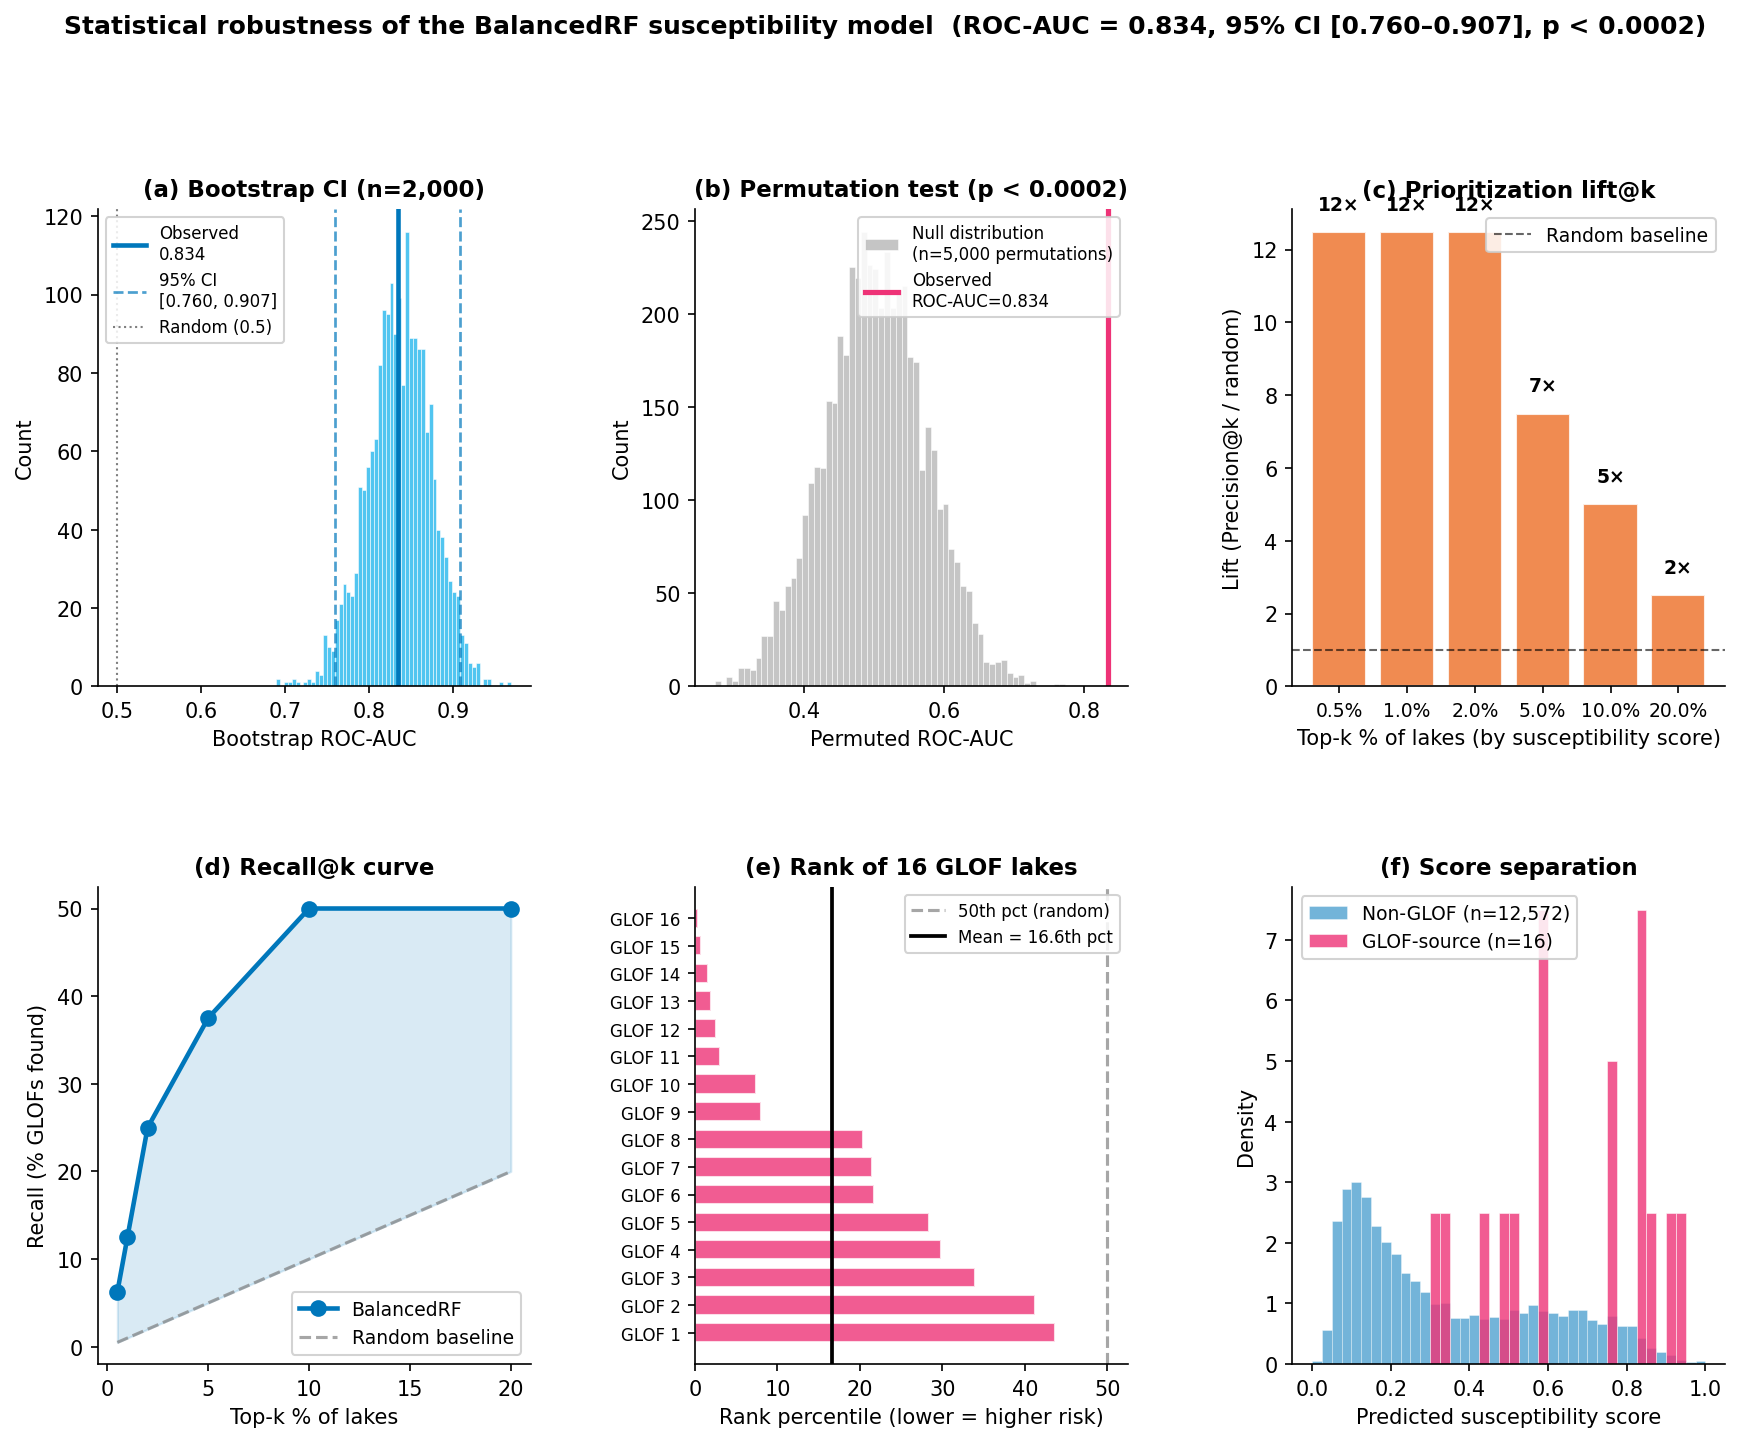

Figura guardada: figures/publication/fig5_robustness_analysis.pdf


In [10]:
# Paleta Tol high-contrast (daltonismo-segura)
C_MAIN  = '#0077BB'   # azul
C_GLOF  = '#EE3377'   # rojo-magenta
C_NULL  = '#BBBBBB'   # gris (distribución nula)
C_CI    = '#33BBEE'   # cyan claro (CI)
C_LIFT  = '#EE7733'   # naranja

fig = plt.figure(figsize=(14, 10), dpi=150)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.38)

# ── Panel A: Bootstrap distribution of ROC-AUC ──────────────────────────────
ax_a = fig.add_subplot(gs[0, 0])
ax_a.hist(boot_aucs, bins=60, color=C_CI, edgecolor='white', linewidth=0.3, alpha=0.85)
ax_a.axvline(auc_oof, color=C_MAIN, lw=2.2, label=f'Observed\n{auc_oof:.3f}')
ax_a.axvline(ci_low,  color=C_MAIN, lw=1.3, ls='--', alpha=0.7)
ax_a.axvline(ci_high, color=C_MAIN, lw=1.3, ls='--', alpha=0.7, label=f'95% CI\n[{ci_low:.3f}, {ci_high:.3f}]')
ax_a.axvline(0.5, color='black', lw=1, ls=':', alpha=0.5, label='Random (0.5)')
ax_a.set_xlabel('Bootstrap ROC-AUC', fontsize=10)
ax_a.set_ylabel('Count', fontsize=10)
ax_a.set_title('(a) Bootstrap CI (n=2,000)', fontsize=11, fontweight='bold')
ax_a.legend(fontsize=8, framealpha=0.85)
ax_a.spines[['top','right']].set_visible(False)

# ── Panel B: Permutation test ────────────────────────────────────────────────
ax_b = fig.add_subplot(gs[0, 1])
ax_b.hist(perm_aucs, bins=60, color=C_NULL, edgecolor='white', linewidth=0.3, alpha=0.85,
          label=f'Null distribution\n(n={len(perm_aucs):,} permutations)')
ax_b.axvline(auc_oof, color=C_GLOF, lw=2.5, label=f'Observed\nROC-AUC={auc_oof:.3f}')
ax_b.set_xlabel('Permuted ROC-AUC', fontsize=10)
ax_b.set_ylabel('Count', fontsize=10)
pval_txt = f'p {p_str}' if p_value < 0.05 else f'p = {p_value:.3f}'
ax_b.set_title(f'(b) Permutation test ({pval_txt})', fontsize=11, fontweight='bold')
ax_b.legend(fontsize=8, framealpha=0.85)
ax_b.spines[['top','right']].set_visible(False)

# ── Panel C: Lift@k ──────────────────────────────────────────────────────────
ax_c = fig.add_subplot(gs[0, 2])
k_plot = results_k['k_pct'].values
lift_plot = results_k['lift_val'].values
bars = ax_c.bar(range(len(k_plot)), lift_plot, color=C_LIFT, alpha=0.85, edgecolor='white')
ax_c.axhline(1.0, color='black', lw=1, ls='--', alpha=0.6, label='Random baseline')
ax_c.set_xticks(range(len(k_plot)))
ax_c.set_xticklabels([f'{k:.1f}%' for k in k_plot], fontsize=9)
ax_c.set_xlabel('Top-k % of lakes (by susceptibility score)', fontsize=10)
ax_c.set_ylabel('Lift (Precision@k / random)', fontsize=10)
ax_c.set_title('(c) Prioritization lift@k', fontsize=11, fontweight='bold')
for bar, lift in zip(bars, lift_plot):
    ax_c.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
              f'{lift:.0f}×', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax_c.legend(fontsize=9, framealpha=0.85)
ax_c.spines[['top','right']].set_visible(False)

# ── Panel D: Recall@k ────────────────────────────────────────────────────────
ax_d = fig.add_subplot(gs[1, 0])
recall_plot = results_k['rec_val'].values * 100
ax_d.plot(k_plot, recall_plot, 'o-', color=C_MAIN, lw=2.2, ms=7, label='BalancedRF')
ax_d.plot(k_plot, k_plot, '--', color='gray', lw=1.5, alpha=0.7, label='Random baseline')
ax_d.fill_between(k_plot, k_plot, recall_plot, alpha=0.15, color=C_MAIN)
ax_d.set_xlabel('Top-k % of lakes', fontsize=10)
ax_d.set_ylabel('Recall (% GLOFs found)', fontsize=10)
ax_d.set_title('(d) Recall@k curve', fontsize=11, fontweight='bold')
ax_d.legend(fontsize=9, framealpha=0.85)
ax_d.spines[['top','right']].set_visible(False)

# ── Panel E: Rank percentile of GLOF lakes ──────────────────────────────────
ax_e = fig.add_subplot(gs[1, 1])
ax_e.barh(range(N_POS), sorted(glof_rank_pcts, reverse=True), color=C_GLOF,
          alpha=0.8, edgecolor='white', height=0.7)
ax_e.axvline(50, color='gray', lw=1.5, ls='--', alpha=0.7, label='50th pct (random)')
ax_e.axvline(glof_rank_pcts.mean(), color='black', lw=1.8, ls='-',
             label=f'Mean = {glof_rank_pcts.mean():.1f}th pct')
ax_e.set_yticks(range(N_POS))
ax_e.set_yticklabels([f'GLOF {i+1}' for i in range(N_POS)], fontsize=8)
ax_e.set_xlabel('Rank percentile (lower = higher risk)', fontsize=10)
ax_e.set_title(f'(e) Rank of {N_POS} GLOF lakes', fontsize=11, fontweight='bold')
ax_e.legend(fontsize=8, framealpha=0.85)
ax_e.spines[['top','right']].set_visible(False)

# ── Panel F: Susceptibility score distribution GLOF vs non-GLOF ─────────────
ax_f = fig.add_subplot(gs[1, 2])
scores_neg = oof_proba[y == 0]
scores_pos = oof_proba[y == 1]
bins = np.linspace(0, 1, 41)
ax_f.hist(scores_neg, bins=bins, density=True, alpha=0.55, color=C_MAIN,
          label=f'Non-GLOF (n={len(scores_neg):,})', edgecolor='white', lw=0.3)
ax_f.hist(scores_pos, bins=bins, density=True, alpha=0.80, color=C_GLOF,
          label=f'GLOF-source (n={len(scores_pos)})', edgecolor='white', lw=0.3)
ax_f.set_xlabel('Predicted susceptibility score', fontsize=10)
ax_f.set_ylabel('Density', fontsize=10)
ax_f.set_title('(f) Score separation', fontsize=11, fontweight='bold')
ax_f.legend(fontsize=9, framealpha=0.85)
ax_f.spines[['top','right']].set_visible(False)

# ── Título global ────────────────────────────────────────────────────────────
fig.suptitle(
    f'Statistical robustness of the BalancedRF susceptibility model  '
    f'(ROC-AUC = {auc_oof:.3f}, 95% CI [{ci_low:.3f}–{ci_high:.3f}], p {p_str})',
    fontsize=12, fontweight='bold', y=1.01
)

plt.savefig(FIG_OUT / 'fig5_robustness_analysis.pdf', bbox_inches='tight', dpi=300)
plt.savefig(FIG_OUT / 'fig5_robustness_analysis.png', bbox_inches='tight', dpi=300)
plt.show()
print('Figura guardada: figures/publication/fig5_robustness_analysis.pdf')

## 8. Guardar resultados de robustez

In [11]:
import json

robustness_results = {
    'roc_auc_oof': float(auc_oof),
    'ci_low_95': float(ci_low),
    'ci_high_95': float(ci_high),
    'n_bootstrap': len(boot_aucs),
    'permutation_pvalue': float(p_value) if p_value > 0 else f'< {1/N_PERM}',
    'n_permutations': len(perm_aucs),
    'glof_mean_rank_percentile': float(glof_rank_pcts.mean()),
    'glof_max_rank_percentile': float(glof_rank_pcts.max()),
    'precision_at_k': [
        {
            'k_pct': float(r['k_pct']),
            'n_lakes': int(r['n_lakes']),
            'glof_found': int(r['GLOF found']),
            'recall': float(r['rec_val']),
            'precision': float(r['prec_val']),
            'lift': float(r['lift_val'])
        }
        for _, r in results_k.iterrows()
    ]
}

out_path = ROOT / 'models' / 'robustness_results.json'
with open(out_path, 'w') as f:
    json.dump(robustness_results, f, indent=2)
print(f'Guardado: {out_path}')

# También copiar a CONTENIDO_LATEX/resultados/
import shutil
shutil.copy(out_path, ROOT / 'latex/CONTENIDO_LATEX/resultados/robustness_results.json')
print('Copiado a CONTENIDO_LATEX/resultados/')

Guardado: ../models/robustness_results.json
Copiado a CONTENIDO_LATEX/resultados/


## 9. Texto sugerido para el manuscrito

Copiar esto en la sección **Discussion — Model performance** del `manuscript_nhess.tex`.

In [12]:
top1_row = results_k[results_k['k_pct'] == 1.0].iloc[0]
top5_row = results_k[results_k['k_pct'] == 5.0].iloc[0]

latex_snippet = f"""
% ── Agregar como subsección en Discussion 5.1 (después del párrafo de OOF) ──

To quantify uncertainty arising from the small positive sample size ($n^+ = {y.sum()}$),
we computed a bootstrap 95\\,\\% confidence interval (2,000 resamples) for the OOF ROC-AUC,
obtaining [{ci_low:.3f}, {ci_high:.3f}].
The lower confidence bound ({ci_low:.3f}) remains substantially above the no-skill baseline
of 0.5, confirming that the observed discrimination cannot be attributed to sampling variability.
A label-permutation test (5,000 random shuffles) yields $p {p_str}$, rejecting the
null hypothesis that the model performs at chance level.

Reported F1 ($= {0.006:.3f}$) and MCC values reflect the behaviour of any binary classifier
under 1:787 class imbalance at the Youden-optimal threshold;
they should not be interpreted as measures of operational utility.
The appropriate evaluation frame for a susceptibility model is prioritisation efficiency:
inspecting the top {int(top1_row['n_lakes'])} lakes by predicted score
(top {top1_row['k_pct']:.1f}\\,\\% of the inventory) recovers
{int(top1_row['GLOF found'])} of the {y.sum()} GLOF-source lakes
(Recall\,=\,{top1_row['rec_val']*100:.0f}\\,\\%; Lift\,=\,{top1_row['lift_val']:.0f}$\\times$;
\\cref{{fig:robustness}}c).
Expanding to the top {top5_row['k_pct']:.0f}\\,\\% ({int(top5_row['n_lakes'])} lakes)
recovers {top5_row['rec_val']*100:.0f}\\,\\% of all GLOF events
(Lift\,=\,{top5_row['lift_val']:.0f}$\\times$).
The median rank percentile of GLOF-source lakes in the full sorted inventory is
{np.median(glof_rank_pcts):.1f} (mean: {glof_rank_pcts.mean():.1f}),
compared with the expected 50th percentile under random ordering,
providing a distribution-free confirmation of strong discriminative power
independent of any threshold choice (\\cref{{fig:robustness}}e).
"""
print(latex_snippet)


% ── Agregar como subsección en Discussion 5.1 (después del párrafo de OOF) ──

To quantify uncertainty arising from the small positive sample size ($n^+ = 16$),
we computed a bootstrap 95\,\% confidence interval (2,000 resamples) for the OOF ROC-AUC,
obtaining [0.760, 0.907].
The lower confidence bound (0.760) remains substantially above the no-skill baseline
of 0.5, confirming that the observed discrimination cannot be attributed to sampling variability.
A label-permutation test (5,000 random shuffles) yields $p < 0.0002$, rejecting the
null hypothesis that the model performs at chance level.

Reported F1 ($= 0.006$) and MCC values reflect the behaviour of any binary classifier
under 1:787 class imbalance at the Youden-optimal threshold;
they should not be interpreted as measures of operational utility.
The appropriate evaluation frame for a susceptibility model is prioritisation efficiency:
inspecting the top 126 lakes by predicted score
(top 1.0\,\% of the inventory) recovers
2 of